# Aviation Safety Incident Clustering Pipeline

Combined pipeline: **CSV load** → **Semantic enrichment** → **Sentence embeddings** → **PCA** → **UMAP** → **HDBSCAN** (with parameter tuning) → **Cluster evidence** → **EurON LLM labeling** → **Plotly visualization**.

In [1]:
# Dependencies are preinstalled externally for reproducible runs.
# Keep this cell lightweight to avoid long/hanging installs during full execution.
import sys
print('python:', sys.executable)
print('setup cell skipped: using existing environment')


python: /opt/anaconda3/bin/python
setup cell skipped: using existing environment


In [2]:
import sys

# Install into the currently running kernel's interpreter.
!{sys.executable} -m pip install -q -U torch torchvision torchaudio

import torch, torchvision
print('torch:', torch.__version__)
print('torchvision:', torchvision.__version__)

torch: 2.11.0
torchvision: 0.26.0


In [3]:
import torch, torchvision
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("cuda available:", torch.cuda.is_available())
print("gpu:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else None)

torch: 2.11.0
torchvision: 0.26.0
cuda available: False
gpu: None


## 1. Config

In [4]:
import os
os.environ["EURON_API_KEY"] = "euri-dd70849e83b4f2d072ab1aaa579357836802709bd365491ccf851a75a99f70b8"
import re
import json
import hashlib
import requests
import numpy as np
import pandas as pd

DATA_CSV = "master_asrs.csv"
DATA_EXCEL = None

EURON_API_KEY = os.environ.get("EURON_API_KEY", "")
EURON_URL = "https://api.euron.one/api/v1/euri/chat/completions"  # no longer used if using local Llama
EURON_MODEL = "gpt-4.1-nano"  # no longer used if using local Llama
# EurON may default max_tokens very high; some models cap completion (e.g. 32768) — set an explicit ceiling.
EURON_MAX_COMPLETION_TOKENS = 4096

# --- Local LLM (Colab) for cluster labels/analysis ---
# IMPORTANT: many Llama weights are gated on Hugging Face; set HF_TOKEN in Colab secrets if needed.
USE_LOCAL_LLM_FOR_LABELS = True
LOCAL_LLM_MODEL_ID = os.environ.get("LOCAL_LLM_MODEL_ID", "meta-llama/Meta-Llama-3.1-8B-Instruct").strip()
# T4-friendly defaults
LOCAL_LLM_MAX_NEW_TOKENS = 500
LOCAL_LLM_TEMPERATURE = 0.0

HDBSCAN_MIN_CLUSTER_SIZES = [25, 30, 40, 50]
HDBSCAN_MIN_SAMPLES = 10
HDBSCAN_METRIC = "euclidean"

# Local embeddings model (BGE) — replaces MiniLM and avoids EurON quota.
EMBEDDING_MODEL = "BAAI/bge-base-en-v1.5"

PCA_DIMS = 50
UMAP_N_NEIGHBORS = 15
UMAP_N_COMPONENTS = 10
UMAP_MIN_DIST = 0.0
UMAP_METRIC = "cosine"
RANDOM_STATE = 42

# Cost/time control for ASRS embeddings (local)
ASRS_EMBED_MAX_CHARS = 1200          # truncate each report text before embedding
ASRS_EMBED_DEDUPE = True             # embed unique texts only, reuse vectors
ASRS_EMBED_BATCH_SIZE = 64

# FAA RAG chunking (PDF/TXT → chunks)
FAA_RAG_CHUNK_TOKENS = 256
FAA_RAG_CHUNK_OVERLAP = 48

_BASE_DIR = os.path.dirname(os.path.abspath(DATA_CSV)) if DATA_CSV else os.getcwd()
CHROMA_PERSIST_DIR = os.path.join(_BASE_DIR, "chroma_asrs_store")
EMBEDDINGS_NPZ = os.path.join(_BASE_DIR, "embeddings_cache.npz")
FORCE_RE_EMBED = False

RECENT_SPIKE_MONTHS = 3
TOP_N_RECENT_SPIKE_CLUSTERS = 5

# --- FAA regulation RAG (separate vector store from ASRS Chroma) ---
FAA_CORPUS_DIR = os.path.join(_BASE_DIR, "faa_corpus")
FAA_CHROMA_DIR = os.path.join(_BASE_DIR, "chroma_faa_regulations")
FAA_RAG_TOP_K = 5
FORCE_REBUILD_FAA_RAG = False

# FAA RAG chunking + embedding model (local BGE)
FAA_RAG_CHUNK_TOKENS = 256
FAA_RAG_CHUNK_OVERLAP = 48


## 2. Load data (CSV) and build full text

In [5]:
if DATA_EXCEL:
    df = pd.read_excel(DATA_EXCEL)
else:
    df = pd.read_csv(DATA_CSV, low_memory=False)


def parse_asrs_month_series(s):
    """Parse ASRS Date: usually YYYYMM as int/float (e.g. 202401). Also accepts datetimes/strings."""
    s = pd.Series(s, dtype="object")
    out = pd.Series(pd.NaT, index=s.index, dtype="datetime64[ns]")
    num = pd.to_numeric(s, errors="coerce")
    yyyymm = num.notna() & (num >= 190001) & (num <= 210012)
    if yyyymm.any():
        codes = num[yyyymm].round().astype("Int64").astype(str)
        out.loc[yyyymm] = pd.to_datetime(codes, format="%Y%m", errors="coerce").values
    rest = out.isna()
    if rest.any():
        out.loc[rest] = pd.to_datetime(s[rest], errors="coerce")
    return pd.to_datetime(out, errors="coerce")


if "Synopsis" in df.columns:
    df["full_text"] = (df["Narrative"].fillna("") + " " + df["Synopsis"].fillna("")).str.lower()
else:
    df["full_text"] = df["Narrative"].fillna("").str.lower()

df = df[df["full_text"].str.len() >= 30].copy()
df.reset_index(drop=True, inplace=True)

if "Date" in df.columns:
    df["date_fixed"] = parse_asrs_month_series(df["Date"])
    print(
        "Shape:",
        df.shape,
        "| date_fixed ok:",
        round(df["date_fixed"].notna().mean(), 3),
        "|",
        df["date_fixed"].min(),
        "->",
        df["date_fixed"].max(),
    )
else:
    print("Shape:", df.shape, "(no Date column)")


Shape: (9789, 252) | date_fixed ok: 1.0 | 2015-01-01 00:00:00 -> 2025-11-01 00:00:00


## 3. Semantic enrichment (keyword-based)

In [6]:
SYSTEM_KEYWORDS = {
    "engine": ["engine", "thrust", "power loss", "stall"],
    "hydraulic": ["hydraulic"],
    "flight_control": ["rudder", "aileron", "elevator", "flight control"],
    "automation": ["autopilot", "fms", "flight director"],
    "tcas": ["tcas", "ra"],
    "electrical": ["electrical", "generator"],
    "fuel": ["fuel leak", "fuel imbalance"],
    "landing_gear": ["landing gear"],
    "pressurization": ["pressur", "cabin altitude"],
    "brakes": ["brake"],
}

def detect_system(text):
    for system, keywords in SYSTEM_KEYWORDS.items():
        for kw in keywords:
            if kw in text:
                return system
    return "unknown"

df["system_category"] = df["full_text"].apply(detect_system)

AUTOMATION_KEYWORDS = ["autopilot", "fms", "flight director", "tcas", "lnav", "vnav"]
df["automation_flag"] = df["full_text"].apply(lambda t: 1 if any(k in t for k in AUTOMATION_KEYWORDS) else 0)

WEATHER_KEYWORDS = ["turbulence", "icing", "wind shear", "microburst", "crosswind", "thunderstorm", "wake vortex"]
df["weather_flag"] = df["full_text"].apply(lambda t: 1 if any(k in t for k in WEATHER_KEYWORDS) else 0)

HUMAN_FACTOR_MAP = {"fatigue": ["fatigue", "tired"], "distraction": ["distract"], "communication": ["misunderstood", "communication", "hearback"], "training": ["training", "inexperience"], "workload": ["workload", "task saturation"]}
def detect_human_factor(text):
    for cat, kws in HUMAN_FACTOR_MAP.items():
        if any(kw in text for kw in kws):
            return cat
    return "none"
df["human_factor_category"] = df["full_text"].apply(detect_human_factor)

SEVERITY_KEYWORDS = {5: ["fire", "smoke", "engine shutdown", "loss of control"], 4: ["emergency", "mayday", "pan pan"], 3: ["priority handling"], 2: ["go around"]}
def severity_score(text):
    for score, kws in SEVERITY_KEYWORDS.items():
        if any(kw in text for kw in kws):
            return score
    return 1
df["severity_score"] = df["full_text"].apply(severity_score)

ANOMALY_MAP = {"Conflict": "airspace_conflict", "Altitude Deviation": "altitude_excursion", "Equipment Problem": "system_failure", "Runway Incursion": "runway_event"}
def normalize_anomaly(value):
    if pd.isna(value): return "unknown"
    v = str(value).lower()
    for key in ANOMALY_MAP:
        if key.lower() in v: return ANOMALY_MAP[key]
    return "other"
df["anomaly_normalized"] = df["Anomaly"].apply(normalize_anomaly) if "Anomaly" in df.columns else "unknown"

print("Enrichment columns:", [c for c in df.columns if c in ["system_category", "automation_flag", "weather_flag", "human_factor_category", "severity_score", "anomaly_normalized"]])

Enrichment columns: ['system_category', 'automation_flag', 'weather_flag', 'human_factor_category', 'severity_score', 'anomaly_normalized']


## 4. Sentence embeddings (Sentence Transformer)

In [7]:
import chromadb
from sentence_transformers import SentenceTransformer


def _data_fingerprint(df):
    h = hashlib.sha256()
    h.update(str(len(df)).encode())
    if "ACN" in df.columns:
        h.update(pd.util.hash_pandas_object(df["ACN"], index=False).values.tobytes())
    h.update(str(int(df["full_text"].str.len().sum())).encode())
    # Include embedding backend so caches don't collide across models/providers
    h.update(str(EMBEDDING_MODEL).encode())
    h.update(str(ASRS_EMBED_MAX_CHARS).encode())
    h.update(str(ASRS_EMBED_DEDUPE).encode())
    return h.hexdigest()


fp = _data_fingerprint(df)
embeddings = None

if not FORCE_RE_EMBED and os.path.isfile(EMBEDDINGS_NPZ):
    z = np.load(EMBEDDINGS_NPZ, allow_pickle=True)
    if str(z["fingerprint"]) == fp and z["embeddings"].shape[0] == len(df):
        embeddings = z["embeddings"]
        print("Loaded embeddings from", EMBEDDINGS_NPZ, embeddings.shape)

if embeddings is None:
    # Cost/time control: truncate long reports and (optionally) dedupe identical texts before embedding.
    model = SentenceTransformer(EMBEDDING_MODEL, device="cuda" if torch.cuda.is_available() else "cpu")

    raw_texts = df["full_text"].fillna("").astype(str).tolist()
    texts = [t[:ASRS_EMBED_MAX_CHARS] for t in raw_texts]

    if ASRS_EMBED_DEDUPE:
        uniq = {}
        order = []
        for t in texts:
            if t not in uniq:
                uniq[t] = None
                order.append(t)
        print("Embedding unique texts:", len(order), "out of", len(texts))
        uniq_vecs = model.encode(
            order,
            show_progress_bar=True,
            batch_size=ASRS_EMBED_BATCH_SIZE,
            normalize_embeddings=True,
        )
        for t, v in zip(order, uniq_vecs):
            uniq[t] = v
        embeddings = np.stack([uniq[t] for t in texts], axis=0)
    else:
        embeddings = model.encode(
            texts,
            show_progress_bar=True,
            batch_size=ASRS_EMBED_BATCH_SIZE,
            normalize_embeddings=True,
        )

    np.savez_compressed(EMBEDDINGS_NPZ, embeddings=embeddings, fingerprint=fp)
    print("Saved embeddings to", EMBEDDINGS_NPZ, embeddings.shape)

os.makedirs(CHROMA_PERSIST_DIR, exist_ok=True)
_client = chromadb.PersistentClient(path=CHROMA_PERSIST_DIR)
_coll = _client.get_or_create_collection(name="asrs_incidents", metadata={"hnsw:space": "cosine"})

_skip_chroma_upsert = False
try:
    n_exist = _coll.count()
    if not FORCE_RE_EMBED and n_exist == len(df):
        any_id = _coll.get(limit=1, include=["metadatas"])["ids"][0]
        md = _coll.get(ids=[any_id], include=["metadatas"])["metadatas"][0]
        if md.get("fingerprint") == fp:
            _skip_chroma_upsert = True
            print("Chroma vectors up to date; skipping embedding upsert.")
except Exception as ex:
    print("Chroma fingerprint check:", ex)

if not _skip_chroma_upsert:
    _ids = []
    _docs = []
    _mds = []
    for i in range(len(df)):
        acn = str(df["ACN"].iloc[i]) if "ACN" in df.columns else f"row_{i}"
        _ids.append(acn)
        _docs.append(str(df["full_text"].iloc[i])[:8000])
        dm = {"fingerprint": fp, "row_index": int(i)}
        if "date_fixed" in df.columns and pd.notna(df["date_fixed"].iloc[i]):
            dm["month"] = str(df["date_fixed"].iloc[i].strftime("%Y-%m"))
        _mds.append(dm)
    _bs = 2000
    for start in range(0, len(_ids), _bs):
        sl = slice(start, start + _bs)
        _coll.upsert(
            ids=_ids[sl],
            embeddings=embeddings[sl].tolist(),
            documents=_docs[sl],
            metadatas=_mds[sl],
        )
    print("Chroma upserted", len(_ids), "vectors ->", CHROMA_PERSIST_DIR)


Loaded embeddings from /Users/avantikatiwarii/Desktop/capston project FINAL/embeddings_cache.npz (9789, 768)
Chroma upserted 9789 vectors -> /Users/avantikatiwarii/Desktop/capston project FINAL/chroma_asrs_store


## 5. Dimensionality reduction: PCA → UMAP

In [8]:
from sklearn.decomposition import PCA
import umap

pca = PCA(n_components=PCA_DIMS, random_state=RANDOM_STATE)
embeddings_pca = pca.fit_transform(embeddings)

umap_model = umap.UMAP(n_neighbors=UMAP_N_NEIGHBORS, n_components=UMAP_N_COMPONENTS, min_dist=UMAP_MIN_DIST, metric=UMAP_METRIC, random_state=RANDOM_STATE)
embeddings_umap = umap_model.fit_transform(embeddings_pca)
print("UMAP shape:", embeddings_umap.shape)

/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP shape: (9789, 10)


## 6. HDBSCAN with parameter tuning (optimal clusters vs noise)

In [9]:
import hdbscan

tuning_results = []
for mcs in HDBSCAN_MIN_CLUSTER_SIZES:
    clusterer = hdbscan.HDBSCAN(min_cluster_size=mcs, min_samples=HDBSCAN_MIN_SAMPLES, metric=HDBSCAN_METRIC)
    labels = clusterer.fit_predict(embeddings_umap)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_pct = (labels == -1).mean() * 100
    tuning_results.append({"min_cluster_size": mcs, "n_clusters": n_clusters, "noise_pct": round(noise_pct, 2)})

tuning_df = pd.DataFrame(tuning_results)
print(tuning_df.to_string(index=False))
print("\nPick MIN_CLUSTER_SIZE (e.g. balance n_clusters and noise_pct). Setting default to 30.")
CHOSEN_MIN_CLUSTER_SIZE = 30  # change after inspecting tuning_df

 min_cluster_size  n_clusters  noise_pct
               25          51      26.69
               30          44      22.61
               40          37      24.66
               50          35      26.40

Pick MIN_CLUSTER_SIZE (e.g. balance n_clusters and noise_pct). Setting default to 30.


In [10]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=CHOSEN_MIN_CLUSTER_SIZE, min_samples=HDBSCAN_MIN_SAMPLES, metric=HDBSCAN_METRIC)
df["cluster_id"] = clusterer.fit_predict(embeddings_umap)
n_clusters = len(set(df["cluster_id"])) - (1 if (df["cluster_id"] == -1).any() else 0)
noise_pct = (df["cluster_id"] == -1).mean() * 100
print(f"Clusters (excl. noise): {n_clusters}, Noise: {noise_pct:.2f}%")

Clusters (excl. noise): 44, Noise: 22.61%


In [11]:
# Number of clusters (excluding noise label -1)
n_clusters = df["cluster_id"].nunique() - (1 if -1 in df["cluster_id"].values else 0)
print(f"Number of clusters: {n_clusters}")

Number of clusters: 44


In [12]:
from sklearn.metrics import silhouette_score

# Exclude noise (-1) for silhouette (metric undefined for single-cluster or noise-only)
mask = df["cluster_id"] != -1
X_clustered = embeddings_umap[mask]
labels_clustered = df.loc[mask, "cluster_id"].values

if len(np.unique(labels_clustered)) > 1:
    sil_score = silhouette_score(X_clustered, labels_clustered)
    print(f"Silhouette Score: {sil_score:.4f}")
else:
    print("Silhouette Score: N/A (need at least 2 clusters)")

Silhouette Score: 0.5133


## 6b. Cluster purity and validation

In [13]:
from scipy.stats import entropy

def cluster_validation(df, column):
    results = []
    for cluster in df["cluster_id"].unique():
        if cluster == -1:
            continue
        subset = df[df["cluster_id"] == cluster]
        if column not in subset.columns:
            continue
        counts = subset[column].value_counts()
        if len(counts) == 0:
            continue
        dominant_ratio = counts.iloc[0] / len(subset)
        ent = entropy(counts.values)
        results.append({
            "cluster": cluster,
            "size": len(subset),
            "dominant_label": counts.index[0],
            "purity": round(dominant_ratio, 3),
            "entropy": round(ent, 3)
        })
    return pd.DataFrame(results)

df_valid = df[df["cluster_id"] != -1].copy()
print("Cluster validation (excluding noise). Columns: cluster, size, dominant_label, purity, entropy.")

Cluster validation (excluding noise). Columns: cluster, size, dominant_label, purity, entropy.


In [14]:
# Purity by Anomaly (or anomaly_normalized)
col = "anomaly_normalized" if "anomaly_normalized" in df_valid.columns else "Anomaly"
if col in df_valid.columns:
    anomaly_validation = cluster_validation(df_valid, col)
    print("--- By Anomaly (top 5 purity) ---")
    print(anomaly_validation.sort_values("purity", ascending=False).head().to_string(index=False))
else:
    print("Anomaly column not found.")

--- By Anomaly (top 5 purity) ---
 cluster  size dominant_label  purity  entropy
      25   103 system_failure     1.0      0.0
      24    37 system_failure     1.0      0.0
      10    32 system_failure     1.0      0.0
       7    40 system_failure     1.0      0.0
      19    34 system_failure     1.0      0.0


In [15]:
# Purity by Flight Phase
if "Flight Phase" in df_valid.columns:
    phase_validation = cluster_validation(df_valid, "Flight Phase")
    print("--- By Flight Phase (top 5 purity) ---")
    print(phase_validation.sort_values("purity", ascending=False).head().to_string(index=False))
else:
    print("Flight Phase column not found.")

--- By Flight Phase (top 5 purity) ---
 cluster  size   dominant_label  purity  entropy
      43   130 Takeoff / Launch   0.962    0.225
      15  1246             Taxi   0.793    0.836
      39    98          Landing   0.786    0.831
       1   118           Parked   0.771    0.802
      40   130          Landing   0.754    0.889


In [16]:
# Purity by Aircraft (Make Model Name)
if "Make Model Name" in df_valid.columns:
    aircraft_validation = cluster_validation(df_valid, "Make Model Name")
    print("--- By Make Model Name (top 5 purity) ---")
    print(aircraft_validation.sort_values("purity", ascending=False).head().to_string(index=False))
else:
    print("Make Model Name column not found.")

--- By Make Model Name (top 5 purity) ---
 cluster  size                                        dominant_label  purity  entropy
      26    41                                 Commercial Fixed Wing   0.585    1.638
       5   171                                 Commercial Fixed Wing   0.520    2.068
      28   492                                 Commercial Fixed Wing   0.378    2.924
       3   194 Small UAS (At or above 0.55 lbs and less than 55 lbs)   0.371    2.931
       8   233                                 Commercial Fixed Wing   0.369    2.563


In [17]:
# Lowest-purity clusters (by Anomaly) — good candidates for subclustering or review
if "anomaly_validation" in dir() and len(anomaly_validation) > 0:
    print("--- Lowest purity clusters (anomaly) ---")
    print(anomaly_validation.sort_values("purity", ascending=True).head(10).to_string(index=False))
elif "phase_validation" in dir() and len(phase_validation) > 0:
    print("--- Lowest purity clusters (Flight Phase) ---")
    print(phase_validation.sort_values("purity", ascending=True).head(10).to_string(index=False))

# --- Reference column: highest mean purity (optional context for label + causal analysis) ---
def _mean_purity_for_col(df_v, col):
    if col not in df_v.columns:
        return -1.0
    cv = cluster_validation(df_v, col)
    if cv is None or len(cv) == 0:
        return -1.0
    return float(cv["purity"].mean())

_purity_candidates = []
if "anomaly_normalized" in df_valid.columns:
    _purity_candidates.append("anomaly_normalized")
elif "Anomaly" in df_valid.columns:
    _purity_candidates.append("Anomaly")
if "Flight Phase" in df_valid.columns:
    _purity_candidates.append("Flight Phase")
if "Make Model Name" in df_valid.columns:
    _purity_candidates.append("Make Model Name")

_purity_means = {}
for _c in _purity_candidates:
    _m = _mean_purity_for_col(df_valid, _c)
    if _m >= 0:
        _purity_means[_c] = _m

PURITY_REFERENCE_COL = max(_purity_means, key=_purity_means.get) if _purity_means else None
PURITY_REFERENCE_MEAN = _purity_means.get(PURITY_REFERENCE_COL) if PURITY_REFERENCE_COL else None
print(
    "PURITY_REFERENCE_COL (highest mean cluster purity):",
    PURITY_REFERENCE_COL,
    "| mean purity:",
    None if PURITY_REFERENCE_MEAN is None else round(PURITY_REFERENCE_MEAN, 3),
)


def cluster_purity_context(df, cluster_id, col):
    if col is None or col not in df.columns:
        return ""
    sub = df[(df["cluster_id"] == cluster_id) & (df["cluster_id"] != -1)]
    if len(sub) == 0:
        return ""
    vc = sub[col].astype(str).value_counts(normalize=True)
    if len(vc) == 0:
        return ""
    dom = vc.index[0]
    p = float(vc.iloc[0])
    return f"Dominant {col}: {dom} ({100 * p:.1f}% of this cluster)"


--- Lowest purity clusters (anomaly) ---
 cluster  size    dominant_label  purity  entropy
      15  1246 airspace_conflict   0.471    0.951
      16    87    system_failure   0.494    0.787
      38   143             other   0.531    0.848
       4    40             other   0.600    0.673
      40   130             other   0.600    0.800
       8   233    system_failure   0.674    0.671
      29   140             other   0.679    0.841
      32   241             other   0.697    0.805
      37    50             other   0.740    0.644
      22    71    system_failure   0.761    0.706
PURITY_REFERENCE_COL (highest mean cluster purity): anomaly_normalized | mean purity: 0.863


## 7. Cluster evidence (representatives, top_terms, top_anomaly, top_phase, top_aircraft)

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

def build_cluster_evidence(df, embeddings, text_col="full_text", cluster_col="cluster_id", top_k_terms=8, reps_per_cluster=5, max_chars_per_rep=700):
    evidence = []
    df = df.copy()
    df[text_col] = df[text_col].fillna("").astype(str)
    for cid in sorted(df[cluster_col].unique()):
        if cid == -1:
            continue
        cdf = df[df[cluster_col] == cid]
        idx = cdf.index.values
        cemb = embeddings[idx]
        centroid = cemb.mean(axis=0)
        dists = np.linalg.norm(cemb - centroid, axis=1)
        rep_idx = idx[np.argsort(dists)[:reps_per_cluster]]
        reps = [" ".join(df.loc[i, text_col].split())[:max_chars_per_rep] for i in rep_idx]
        # Narrative + Synopsis (same representative rows as embeddings) for causal / analysis prompts
        ns_parts = []
        for i in rep_idx:
            nar = df.loc[i, "Narrative"] if "Narrative" in df.columns else ""
            syn = df.loc[i, "Synopsis"] if "Synopsis" in df.columns else ""
            nar = str(nar) if pd.notna(nar) else ""
            syn = str(syn) if pd.notna(syn) else ""
            block = []
            if nar.strip():
                block.append("Narrative: " + " ".join(nar.split())[:600])
            if syn.strip():
                block.append("Synopsis: " + " ".join(syn.split())[:500])
            if block:
                ns_parts.append("\n".join(block))
        narrative_synopsis_bundle = "\n---\n".join(ns_parts)[:4500]
        vectorizer = TfidfVectorizer(stop_words="english", ngram_range=(1, 2), max_features=2000)
        X = vectorizer.fit_transform(cdf[text_col].tolist())
        terms = np.array(vectorizer.get_feature_names_out())
        scores = np.asarray(X.mean(axis=0)).ravel()
        top_terms = terms[np.argsort(scores)[-top_k_terms:]][::-1].tolist()
        top_anom = cdf["Anomaly"].mode().iloc[0] if "Anomaly" in cdf.columns and not cdf["Anomaly"].mode().empty else "N/A"
        top_phase = cdf["Flight Phase"].mode().iloc[0] if "Flight Phase" in cdf.columns and not cdf["Flight Phase"].mode().empty else "N/A"
        top_aircraft = cdf["Make Model Name"].mode().iloc[0] if "Make Model Name" in cdf.columns and not cdf["Make Model Name"].mode().empty else "N/A"
        evidence.append(
            {
                "cluster_id": cid,
                "size": len(cdf),
                "top_anomaly": top_anom,
                "top_phase": top_phase,
                "top_aircraft": top_aircraft,
                "top_terms": top_terms,
                "representatives": reps,
                "narrative_synopsis_bundle": narrative_synopsis_bundle,
            }
        )
    return pd.DataFrame(evidence)


cluster_evidence = build_cluster_evidence(df, embeddings, text_col="full_text")
if "cluster_purity_context" in dir() and PURITY_REFERENCE_COL is not None:
    cluster_evidence["purity_context"] = cluster_evidence["cluster_id"].apply(
        lambda cid: cluster_purity_context(df, cid, PURITY_REFERENCE_COL)
    )
else:
    cluster_evidence["purity_context"] = ""
cluster_evidence.head()


,cluster_id,size,top_anomaly,top_phase,top_aircraft,top_terms,representatives,narrative_synopsis_bundle,purity_context
0,0,324,Deviation / Discrepancy - Procedural Hazardous...,Parked,B737 Undifferentiated or Other Model,"[dg, flight, dangerous, goods, dangerous goods...",[prior to departure; we received a no dangerou...,Narrative: Prior to departure; we received a N...,Dominant anomaly_normalized: other (92.0% of t...
1,1,118,Deviation / Discrepancy - Procedural FAR; Devi...,Parked,Commercial Fixed Wing,"[battery, passenger, bag, flight, lithium, whe...",[on day 0; dangerous goods were loaded onto ou...,Narrative: On Day 0; Dangerous Goods were load...,Dominant anomaly_normalized: other (91.5% of t...
2,2,166,Airspace Violation All Types; Conflict NMAC; D...,Final Approach,Medium Large Transport; Low Wing; 2 Turbojet Eng,"[drone, approach, aircraft, feet, flight, uas,...",[captain flying. ewr ils04r autopilot engaged ...,Narrative: Captain flying. EWR ILS04R autopilo...,Dominant anomaly_normalized: airspace_conflict...
3,3,194,Airspace Violation All Types; Deviation / Disc...,Cruise,Small UAS (At or above 0.55 lbs and less than ...,"[airspace, drone, flight, uas, laanc, authoriz...",[i recently passed the part 107 exam for a dro...,Narrative: I recently passed the part 107 exam...,Dominant anomaly_normalized: other (83.5% of t...
4,4,40,Airspace Violation All Types; Deviation / Disc...,Cruise,Small UAS (At or above 0.55 lbs and less than ...,"[drone, uas, feet, altitude, flight, ft, 400, ...",[i launched the drone normally and flew approx...,Narrative: I launched the drone normally and f...,Dominant anomaly_normalized: other (60.0% of t...


## 8. EurON: cluster labels + causal analysis (Narrative/Synopsis + purity reference)

Uses **Narrative** and **Synopsis** (same rows as text representatives), plus the **reference column** with **highest mean cluster purity** (among Anomaly / Flight Phase / Make Model Name) for extra structured context. **Chroma** metadata is updated after merge.


In [19]:
_LOCAL_LLM = None
_LOCAL_TOKENIZER = None


def _init_local_llm():
    global _LOCAL_LLM, _LOCAL_TOKENIZER
    if _LOCAL_LLM is not None and _LOCAL_TOKENIZER is not None:
        return

    from transformers import AutoModelForCausalLM, AutoTokenizer

    _LOCAL_TOKENIZER = AutoTokenizer.from_pretrained(LOCAL_LLM_MODEL_ID, use_fast=True)
    _LOCAL_LLM = AutoModelForCausalLM.from_pretrained(
        LOCAL_LLM_MODEL_ID,
        device_map="auto",
        load_in_4bit=True,
        trust_remote_code=True,
    )


def call_llm(prompt: str):
    """Return model text (should be JSON) or None on failure."""
    if not USE_LOCAL_LLM_FOR_LABELS:
        return None
    try:
        _init_local_llm()
        messages = [
            {"role": "system", "content": "Return only valid JSON. No extra text."},
            {"role": "user", "content": prompt},
        ]
        # Llama Instruct uses chat template
        input_ids = _LOCAL_TOKENIZER.apply_chat_template(
            messages,
            add_generation_prompt=True,
            return_tensors="pt",
        ).to(_LOCAL_LLM.device)

        out = _LOCAL_LLM.generate(
            input_ids,
            max_new_tokens=int(LOCAL_LLM_MAX_NEW_TOKENS),
            temperature=float(LOCAL_LLM_TEMPERATURE),
            do_sample=float(LOCAL_LLM_TEMPERATURE) > 0,
            eos_token_id=_LOCAL_TOKENIZER.eos_token_id,
        )
        gen = out[0][input_ids.shape[-1] :]
        text = _LOCAL_TOKENIZER.decode(gen, skip_special_tokens=True)
        return text
    except Exception as e:
        print("Local LLM error:", e)
        return None


def parse_json(text):
    if not text:
        return None
    match = re.search(r"\{.*\}", text, re.DOTALL)
    if not match:
        return None
    try:
        return json.loads(match.group())
    except json.JSONDecodeError:
        return None


def fallback_label(row):
    anomaly = str(row.get("top_anomaly", ""))[:60].strip()
    phase = str(row.get("top_phase", "")).strip()
    aircraft = str(row.get("top_aircraft", "")).strip()[:50]
    terms = row.get("top_terms", [])
    terms = list(terms)[:8] if isinstance(terms, list) else []
    kw = ", ".join(terms) if terms else f"{phase}, {anomaly}"
    name = f"{phase} - {anomaly}" if anomaly else f"Cluster (phase: {phase})"
    if len(name) > 60:
        name = name[:57] + "..."
    desc = f"Incidents in {phase}. Common theme: {anomaly}. Aircraft: {aircraft}."
    return {"name": name, "description": desc, "keywords": kw}


def fallback_analysis(row):
    # Heuristic summary that stays short and user-facing (no copied narratives).
    phase = str(row.get("top_phase", "")).strip()
    anom = str(row.get("top_anomaly", "")).strip()
    ac = str(row.get("top_aircraft", "")).strip()
    terms = row.get("top_terms") or []
    terms = list(terms)[:8] if isinstance(terms, list) else []
    n = int(row.get("size", 0))
    pur = str(row.get("purity_context", "")).strip()

    s1 = f"This cluster has {n} reports, mostly during {phase or 'unknown phase'}."
    s2 = f"The dominant issue pattern is {anom}." if anom else "The dominant issue pattern is not clearly labeled."
    s3 = f"It is most common in {ac} operations." if ac else "It appears across multiple aircraft contexts."
    s4 = f"Frequent terms include: {', '.join(terms)}." if terms else "Recurring language suggests a consistent operational pattern."
    s5 = f"Structured fields are consistent with: {pur}." if pur else "Structured fields provide partial support for this theme."
    summary = " ".join([s1, s2, s3, s4, s5])

    eb = []
    if phase:
        eb.append(f"Phase: {phase}")
    if anom:
        eb.append(f"Anomaly / theme: {anom[:150]}{'...' if len(anom) > 150 else ''}")
    if ac:
        eb.append(f"Aircraft context: {ac}")
    if terms:
        eb.append("Key terms: " + ", ".join(terms[:8]))
    if pur:
        eb.append(pur)
    lim = "Descriptive only; not proven root cause. Ground claims in Narrative/Synopsis and fields above."
    return {
        "causal_summary": summary,
        "evidence_bullets": eb if eb else [summary[:200]],
        "limitations": lim,
    }


def _clean_causal_summary(text, row):
    """Enforce short, plain-language summary and remove copied excerpts."""
    t = " ".join(str(text or "").split())
    low = t.lower()
    banned = ["narrative:", "synopsis:", "themes (excerpts)", "representative text:", "alert"]
    if (not t) or any(b in low for b in banned) or len(t) > 520:
        return fallback_analysis(row)["causal_summary"]
    parts = re.split(r"(?<=[.!?])\s+", t)
    parts = [p.strip() for p in parts if p.strip()]
    return " ".join(parts[:4])


def fallback_all(row):
    b = fallback_label(row)
    c = fallback_analysis(row)
    b["causal_summary"] = _clean_causal_summary(c["causal_summary"], row)
    b["evidence_bullets"] = " | ".join(c["evidence_bullets"])
    b["limitations"] = c["limitations"]
    return b


_ref_col = PURITY_REFERENCE_COL if "PURITY_REFERENCE_COL" in dir() else None
_ref_mean = PURITY_REFERENCE_MEAN if "PURITY_REFERENCE_MEAN" in dir() else None

labels_list = []
for _, row in cluster_evidence.iterrows():
    reps = "\n\n".join([f"- {t}" for t in row["representatives"]])
    ns_block = str(row.get("narrative_synopsis_bundle", "")).strip()
    pur_line = str(row.get("purity_context", "")).strip()
    prompt = (
        "You are an aviation safety analyst. Produce (1) cluster LABELS and (2) CAUSAL / INTERPRETIVE ANALYSIS.\n"
        "Ground everything in the text and fields below. Embeddings were built from the same lowercased Narrative+Synopsis as full_text; "
        "the Narrative/Synopsis block below is the raw source (per representative reports).\n"
        "Return STRICT JSON with keys:\n"
        '  name (short), description (one paragraph), keywords (array or comma-separated string),\n'
        "  causal_summary (2-4 short plain-English sentences for non-experts; summarize likely mechanism and contributing factors; "
        "DO NOT copy or quote Narrative/Synopsis text, DO NOT paste alert text, and avoid jargon where possible),\n"
        "  evidence_bullets (array of 3-6 short strings tying claims to Narrative/Synopsis, Phase, Anomaly, Aircraft, terms, or purity line),\n"
        "  limitations (one sentence on what cannot be concluded).\n"
        f"Cluster size: {row['size']}\nPhase: {row['top_phase']}\nAnomaly: {row['top_anomaly']}\n"
        f"Aircraft: {row['top_aircraft']}\nTop terms: {row['top_terms']}\n"
        f"Reference column (highest mean cluster purity across dataset): {_ref_col} (mean purity ~ {_ref_mean})\n"
        f"Per-cluster dominant value for that column: {pur_line}\n"
        "Representative reports (lowercased full_text excerpts, same rows as Narrative/Synopsis block):\n"
        f"{reps}\n"
        "Narrative and Synopsis (raw text, same representative rows as above):\n"
        f"{ns_block}\n"
    )
    raw = call_llm(prompt)
    if raw is None:
        parsed = fallback_all(row)
    else:
        parsed = parse_json(raw)
        if parsed is None:
            parsed = fallback_all(row)
        else:
            kw = parsed.get("keywords", [])
            parsed["keywords"] = ", ".join(kw) if isinstance(kw, list) else (kw or "")
            eb = parsed.get("evidence_bullets", [])
            if isinstance(eb, list):
                parsed["evidence_bullets"] = " | ".join(str(x) for x in eb)
            else:
                parsed["evidence_bullets"] = str(eb or "")
            for k in ("name", "description", "causal_summary", "limitations"):
                parsed[k] = str(parsed.get(k, "") or "")
            parsed["causal_summary"] = _clean_causal_summary(parsed.get("causal_summary", ""), row)
    labels_list.append(
        {
            "cluster_id": row["cluster_id"],
            "size": row["size"],
            "name": parsed.get("name", ""),
            "description": parsed.get("description", ""),
            "keywords": parsed.get("keywords", ""),
            "causal_summary": parsed.get("causal_summary", ""),
            "evidence_bullets": parsed.get("evidence_bullets", ""),
            "limitations": parsed.get("limitations", ""),
            "top_phase": row["top_phase"],
            "purity_reference_col": _ref_col if _ref_col is not None else "",
            "purity_context": pur_line,
        }
    )

cluster_labels_llm = pd.DataFrame(labels_list).sort_values("size", ascending=False)
print("EurON labels + causal analysis" if EURON_API_KEY else "Fallback labels + causal analysis (no API key)")
cluster_labels_llm.head(10)


Local LLM error: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/meta-llama/Meta-Llama-3.1-8B-Instruct.
401 Client Error. (Request ID: Root=1-69ed425f-4a872be76cc542da1ddaeafe;6b2f6aca-9ef0-4dcb-b9af-6a8adff51243)

Cannot access gated repo for url https://huggingface.co/meta-llama/Meta-Llama-3.1-8B-Instruct/resolve/main/config.json.
Access to model meta-llama/Llama-3.1-8B-Instruct is restricted. You must have access to it and be authenticated to access it. Please log in.
Local LLM error: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/meta-llama/Meta-Llama-3.1-8B-Instruct.
401 Client Error. (Request ID: Root=1-69ed425f-30d40a1d3427ef21287d2de7;31890b9c-cf2a-4571-9245-9893a09b4242)

Cannot access gated repo for url https://huggingface.co/meta-llama/Meta-Llama-3.1-8B-Instruct/resolve/main/config.json.
Access to model meta-llama/Llama-3.1-8B-Instruct is restricted. You must have access to it an

,cluster_id,size,name,description,keywords,causal_summary,evidence_bullets,limitations,top_phase,purity_reference_col,purity_context
15,15,1246,Taxi - Deviation / Discrepancy - Procedural Pu...,Incidents in Taxi. Common theme: Deviation / D...,"aircraft, runway, taxiway, taxi, gate, ground,...","Across 1246 reports, the dominant flight phase...",Phase: Taxi | Anomaly / theme: Deviation / Dis...,Descriptive only; not proven root cause. Groun...,Taxi,anomaly_normalized,Dominant anomaly_normalized: airspace_conflict...
23,23,769,Final Approach - Conflict NMAC; Deviation / Di...,Incidents in Final Approach. Common theme: Con...,"aircraft, runway, traffic, pattern, tower, fin...","Across 769 reports, the dominant flight phase ...",Phase: Final Approach | Anomaly / theme: Confl...,Descriptive only; not proven root cause. Groun...,Final Approach,anomaly_normalized,Dominant anomaly_normalized: airspace_conflict...
17,17,589,Cruise - Inflight Event / Encounter Wake Vorte...,Incidents in Cruise. Common theme: Inflight Ev...,"turbulence, aircraft, wake, flight, wake turbu...","Across 589 reports, the dominant flight phase ...",Phase: Cruise | Anomaly / theme: Inflight Even...,Descriptive only; not proven root cause. Groun...,Cruise,anomaly_normalized,Dominant anomaly_normalized: other (78.1% of t...
28,28,492,Initial Approach - Deviation / Discrepancy - P...,Incidents in Initial Approach. Common theme: D...,"approach, altitude, terrain, visual, atc, airc...","Across 492 reports, the dominant flight phase ...",Phase: Initial Approach | Anomaly / theme: Dev...,Descriptive only; not proven root cause. Groun...,Initial Approach,anomaly_normalized,Dominant anomaly_normalized: other (81.9% of t...
0,0,324,Parked - Deviation / Discrepancy - Procedural ...,Incidents in Parked. Common theme: Deviation /...,"dg, flight, dangerous, goods, dangerous goods,...","Across 324 reports, the dominant flight phase ...",Phase: Parked | Anomaly / theme: Deviation / D...,Descriptive only; not proven root cause. Groun...,Parked,anomaly_normalized,Dominant anomaly_normalized: other (92.0% of t...
12,12,280,Cruise - Aircraft Equipment Problem Critical; ...,Incidents in Cruise. Common theme: Aircraft Eq...,"flight, smoke, aircraft, crew, smell, engine, ...","Across 280 reports, the dominant flight phase ...",Phase: Cruise | Anomaly / theme: Aircraft Equi...,Descriptive only; not proven root cause. Groun...,Cruise,anomaly_normalized,Dominant anomaly_normalized: system_failure (9...
9,9,250,Parked - Aircraft Equipment Problem Critical; ...,Incidents in Parked. Common theme: Aircraft Eq...,"aircraft, maintenance, engine, flight, oil, co...","Across 250 reports, the dominant flight phase ...",Phase: Parked | Anomaly / theme: Aircraft Equi...,Descriptive only; not proven root cause. Groun...,Parked,anomaly_normalized,Dominant anomaly_normalized: system_failure (9...
32,32,241,Initial Approach - Deviation / Discrepancy - P...,Incidents in Initial Approach. Common theme: D...,"approach, altitude, visual, aircraft, atc, zzz...","Across 241 reports, the dominant flight phase ...",Phase: Initial Approach | Anomaly / theme: Dev...,Descriptive only; not proven root cause. Groun...,Initial Approach,anomaly_normalized,Dominant anomaly_normalized: other (69.7% of t...
8,8,233,Parked - Deviation / Discrepancy - Procedural ...,Incidents in Parked. Common theme: Deviation /...,"door, slide, flight, gate, agent, aircraft, ha...","Across 233 reports, the dominant flight phase ...",Phase: Parked | Anomaly / theme: Deviation / D...,Descriptive only; not proven root cause. Groun...,Parked,anomaly_normalized,Dominant anomaly_normalized: system_failure (6...
3,3,194,Cruise - Airspace Violation All Types; Deviati...,Incidents in Cruise. Common theme: Airspace Vi...,"airspace, drone, flight, uas, laanc, authoriza...","Across 194 reports, the dominant flight phase ...",Phase: Cruise | Anomaly / theme: Airspace Viol...,Descriptive only; not proven root cause. Groun...,Cruise,anomaly_normalize

In [20]:
df["cluster_id"] = df["cluster_id"].astype(int)
cluster_labels_llm["cluster_id"] = cluster_labels_llm["cluster_id"].astype(int)
merge_cols = [
    "cluster_id",
    "name",
    "description",
    "causal_summary",
    "evidence_bullets",
    "limitations",
    "purity_reference_col",
    "purity_context",
]
merge_cols = [c for c in merge_cols if c in cluster_labels_llm.columns]
df = df.merge(cluster_labels_llm[merge_cols], on="cluster_id", how="left")
print("Merged cluster labels + causal fields into df.")

_fp_meta = hashlib.sha256()
_fp_meta.update(str(len(df)).encode())
if "ACN" in df.columns:
    _fp_meta.update(pd.util.hash_pandas_object(df["ACN"], index=False).values.tobytes())
_fp_meta.update(str(int(df["full_text"].str.len().sum())).encode())
_fingerprint = _fp_meta.hexdigest()

try:
    import chromadb

    _client = chromadb.PersistentClient(path=CHROMA_PERSIST_DIR)
    _coll = _client.get_collection("asrs_incidents")
    id_col = "ACN" if "ACN" in df.columns else None
    ids_batch = []
    meta_batch = []
    bs = 256
    for i in range(len(df)):
        _id = str(df[id_col].iloc[i]) if id_col else f"row_{i}"
        ids_batch.append(_id)
        meta_batch.append(
            {
                "fingerprint": _fingerprint,
                "row_index": int(i),
                "cluster_id": int(df["cluster_id"].iloc[i]),
                "cluster_name": str(df["name"].iloc[i]) if pd.notna(df["name"].iloc[i]) else "",
                "description": (str(df["description"].iloc[i])[:1900] if "description" in df.columns else ""),
                "causal_summary": (str(df["causal_summary"].iloc[i])[:1900] if "causal_summary" in df.columns else ""),
            }
        )
        if len(ids_batch) >= bs:
            _coll.update(ids=ids_batch, metadatas=meta_batch)
            ids_batch, meta_batch = [], []
    if ids_batch:
        _coll.update(ids=ids_batch, metadatas=meta_batch)
    print("Chroma metadata updated (cluster + causal).")
except Exception as e:
    print("Chroma metadata update skipped:", e)


Merged cluster labels + causal fields into df.
Chroma metadata updated (cluster + causal).


## 9. UMAP 2D for visualization

In [21]:
umap_2d = umap.UMAP(n_neighbors=UMAP_N_NEIGHBORS, n_components=2, min_dist=UMAP_MIN_DIST, metric=UMAP_METRIC, random_state=RANDOM_STATE)
embeddings_2d = umap_2d.fit_transform(embeddings_pca)
df["umap_x"] = embeddings_2d[:, 0]
df["umap_y"] = embeddings_2d[:, 1]
df["cluster_label"] = df["cluster_id"].apply(lambda x: "Noise" if x == -1 else f"Cluster {x}")

/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


## 10. Plotly: cluster name and info

In [22]:
import plotly.express as px

hover_cols = [c for c in ["cluster_label", "name", "description", "ACN", "Date", "Flight Phase", "Make Model Name", "Anomaly", "system_category", "severity_score"] if c in df.columns]
fig = px.scatter(df, x="umap_x", y="umap_y", color="cluster_label", hover_data=hover_cols,
    title="Aviation incidents by cluster (hover: name, description, phase, anomaly)", width=1100, height=700)
fig.update_traces(marker=dict(size=5, opacity=0.8))
fig.update_layout(showlegend=False)
fig.show()

In [23]:
# Optional: bar chart of cluster sizes with names
plot_df = df[df["cluster_id"] != -1].groupby("cluster_id").agg(size=("cluster_id", "count"), name=("name", "first")).reset_index()
fig2 = px.bar(plot_df, x="cluster_id", y="size", hover_data=["name"], title="Cluster sizes (hover for LLM name)")
fig2.show()

In [24]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import numpy as np

# Exclude noise (cluster_id == -1) for clustering metrics
mask = df["cluster_id"] != -1
X_clustered = embeddings_umap[mask]
labels_clustered = df.loc[mask, "cluster_id"].values

n_clusters = len(np.unique(labels_clustered))
noise_pct = (df["cluster_id"] == -1).mean() * 100

print("===== CLUSTER METRICS =====")
if n_clusters > 1:
    sil_score = silhouette_score(X_clustered, labels_clustered)
    db_score = davies_bouldin_score(X_clustered, labels_clustered)
    ch_score = calinski_harabasz_score(X_clustered, labels_clustered)
    print(f"Silhouette Score: {sil_score:.4f}")
    print(f"Davies-Bouldin Score: {db_score:.4f}")
    print(f"Calinski-Harabasz Score: {ch_score:.4f}")
else:
    print("Silhouette Score: N/A (need at least 2 clusters)")
    print("Davies-Bouldin Score: N/A")
    print("Calinski-Harabasz Score: N/A")
print(f"Noise Percentage: {noise_pct:.2f}%")

===== CLUSTER METRICS =====
Silhouette Score: 0.5133
Davies-Bouldin Score: 0.5690
Calinski-Harabasz Score: 6178.8525
Noise Percentage: 22.61%


11. Time-Series Trend Detection on Clustered Reports (Counts + Share)

In [25]:
# ============================================================
# TIME SERIES TREND DETECTION FOR CLUSTERED ASRS REPORTS
# ============================================================
# Purpose:
# This code analyzes how each cluster changes over time and
# flags unusual "spike" months.
#
# Main idea:
# - Convert the broken Date column into real monthly dates
# - Count how many reports belong to each cluster each month
# - Normalize by total report volume that month
# - Compute rolling mean / rolling std
# - Flag unusually large increases using z-score and growth %
#
# Expected input:
# A dataframe named `df` with at least:
#   - "Date" column
#   - "cluster_id" column
#
# Optional:
#   - cluster_id == -1 is treated as noise and can be excluded
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px


# ============================================================
# 1. CONFIGURATION
# ============================================================

DATE_COL = "Date"              # Name of the date column
CLUSTER_COL = "cluster_id"     # Name of the cluster label column

INCLUDE_NOISE = False          # If False, exclude cluster_id == -1
ROLLING_WINDOW = 6             # Number of months for rolling baseline

# Thresholds used to flag spikes
RATE_Z_THRESHOLD = 3.0         # High relative-to-history spike
RATE_GROWTH_THRESHOLD = 200.0  # 200% = current month is 3x previous month
MIN_BASELINE_COUNT = 5         # Avoid tiny-count false alarms

TOP_N_HEATMAP = 30             # Number of top clusters to show in heatmap

In [26]:
# ============================================================
# 2. INSPECT THE ORIGINAL DATE COLUMN
# ============================================================
# Your Date column appears to be incorrectly stored as datetime64[ns],
# where the nanosecond integer actually contains a YYYYMM code.
#
# Example:
# 1970-01-01 00:00:00.000202401
# Under the hood, int64 = 202401
# which should be interpreted as January 2024

print("Original dtype:", df[DATE_COL].dtype)
print(df[DATE_COL].head())
print("Original Min/Max:", df[DATE_COL].min(), "→", df[DATE_COL].max())

Original dtype: float64
0    202401.0
1    202401.0
2    202401.0
3    202401.0
4    202401.0
Name: Date, dtype: float64
Original Min/Max: 201501.0 → 202511.0


In [27]:
# date_fixed is created when loading data (parse_asrs_month_series).
if "date_fixed" not in df.columns and "Date" in df.columns:
    df["date_fixed"] = parse_asrs_month_series(df["Date"])

if "Date" in df.columns:
    print(df[["Date", "date_fixed"]].head(10))
    print("date_fixed range:", df["date_fixed"].min(), "->", df["date_fixed"].max(), "ok:", df["date_fixed"].notna().mean())
else:
    print("No Date column.")


       Date date_fixed
0  202401.0 2024-01-01
1  202401.0 2024-01-01
2  202401.0 2024-01-01
3  202401.0 2024-01-01
4  202401.0 2024-01-01
5  202401.0 2024-01-01
6  202401.0 2024-01-01
7  202401.0 2024-01-01
8  202401.0 2024-01-01
9  202401.0 2024-01-01
date_fixed range: 2015-01-01 00:00:00 -> 2025-11-01 00:00:00 ok: 1.0


In [28]:
# ============================================================
# 4. CLEAN THE DATA
# ============================================================
# Keep only rows with valid parsed dates.
# Optionally remove the noise cluster.

df_ts = df.dropna(subset=["date_fixed"]).copy()

if not INCLUDE_NOISE:
    df_ts = df_ts[df_ts[CLUSTER_COL] != -1].copy()

# Convert each date to month-start so all reports in the same month
# share one common time key.
df_ts["month_key"] = df_ts["date_fixed"].dt.to_period("M").dt.to_timestamp(how="start")

print("\nNumber of unique months:", df_ts["month_key"].nunique())
print(df_ts[[CLUSTER_COL, "date_fixed", "month_key"]].head())


Number of unique months: 27
   cluster_id date_fixed  month_key
0           5 2024-01-01 2024-01-01
1          18 2024-01-01 2024-01-01
2          27 2024-01-01 2024-01-01
3          15 2024-01-01 2024-01-01
4          23 2024-01-01 2024-01-01


In [29]:
# ============================================================
# 5. COMPUTE TOTAL MONTHLY REPORT VOLUME
# ============================================================
# This gives the total number of reports in each month, regardless
# of cluster. We use this later to normalize cluster counts.
#
# Why normalize?
# If one month simply has more total reports overall, a cluster may
# look like it increased even if its *share* stayed normal.

monthly_total = (
    df_ts.groupby("month_key")
         .size()
         .reset_index(name="month_total")
         .sort_values("month_key")
)

print("\nMonthly totals:")
print(monthly_total.head())
print(monthly_total.tail())


Monthly totals:
   month_key  month_total
0 2015-01-01            1
1 2015-03-01            1
2 2023-02-01            1
3 2023-03-01            1
4 2024-01-01          315
    month_key  month_total
22 2025-07-01          353
23 2025-08-01          401
24 2025-09-01          379
25 2025-10-01          213
26 2025-11-01           18


In [30]:
# ============================================================
# 6. COMPUTE MONTHLY CLUSTER COUNTS
# ============================================================
# Count how many reports belong to each cluster in each month.

cluster_month = (
    df_ts.groupby([CLUSTER_COL, "month_key"])
         .size()
         .reset_index(name="count")
         .sort_values([CLUSTER_COL, "month_key"])
)

print("\nCluster-month counts:")
print(cluster_month.head(10))


Cluster-month counts:
   cluster_id  month_key  count
0           0 2024-01-01     16
1           0 2024-02-01     20
2           0 2024-03-01     22
3           0 2024-04-01     23
4           0 2024-05-01     31
5           0 2024-06-01     21
6           0 2024-07-01     21
7           0 2024-08-01     22
8           0 2024-09-01     26
9           0 2024-10-01     10


In [31]:
# ============================================================
# 7. MERGE MONTHLY TOTALS AND COMPUTE NORMALIZED RATE
# ============================================================
# rate = cluster_count / total_reports_that_month
#
# Example:
# If cluster 3 has 20 reports in a month with 200 total reports,
# then rate = 20 / 200 = 0.10 (10%)

cluster_month = cluster_month.merge(monthly_total, on="month_key", how="left")
cluster_month["rate"] = cluster_month["count"] / cluster_month["month_total"]

print("\nCluster-month with normalized rate:")
print(cluster_month.head(10))



Cluster-month with normalized rate:
   cluster_id  month_key  count  month_total      rate
0           0 2024-01-01     16          315  0.050794
1           0 2024-02-01     20          292  0.068493
2           0 2024-03-01     22          392  0.056122
3           0 2024-04-01     23          401  0.057357
4           0 2024-05-01     31          377  0.082228
5           0 2024-06-01     21          362  0.058011
6           0 2024-07-01     21          334  0.062874
7           0 2024-08-01     22          350  0.062857
8           0 2024-09-01     26          283  0.091873
9           0 2024-10-01     10          315  0.031746


In [32]:
# ============================================================
# 8. BUILD A DENSE CLUSTER-MONTH TABLE
# ============================================================
# Some clusters may not appear in every month.
# To do proper time-series analysis, we create a complete grid:
# every cluster x every month
#
# Missing combinations are filled with count = 0.

all_months = pd.date_range(
    start=monthly_total["month_key"].min(),
    end=monthly_total["month_key"].max(),
    freq="MS"   # month start
)

all_clusters = cluster_month[CLUSTER_COL].unique()

dense_index = pd.MultiIndex.from_product(
    [all_clusters, all_months],
    names=[CLUSTER_COL, "month_key"]
)

cluster_month_dense = (
    cluster_month.set_index([CLUSTER_COL, "month_key"])
                 .reindex(dense_index)
                 .reset_index()
                 .sort_values([CLUSTER_COL, "month_key"])
)

# Fill missing counts with zero
cluster_month_dense["count"] = cluster_month_dense["count"].fillna(0)

# Re-attach monthly totals and recompute rate cleanly
cluster_month_dense = (
    cluster_month_dense.drop(columns=["month_total", "rate"], errors="ignore")
                       .merge(monthly_total, on="month_key", how="left")
)

cluster_month_dense["rate"] = cluster_month_dense["count"] / cluster_month_dense["month_total"]

print("\nDense cluster-month table:")
print(cluster_month_dense.head(15))



Dense cluster-month table:
    cluster_id  month_key  count  month_total  rate
0            0 2015-01-01    0.0          1.0   0.0
1            0 2015-02-01    0.0          NaN   NaN
2            0 2015-03-01    0.0          1.0   0.0
3            0 2015-04-01    0.0          NaN   NaN
4            0 2015-05-01    0.0          NaN   NaN
5            0 2015-06-01    0.0          NaN   NaN
6            0 2015-07-01    0.0          NaN   NaN
7            0 2015-08-01    0.0          NaN   NaN
8            0 2015-09-01    0.0          NaN   NaN
9            0 2015-10-01    0.0          NaN   NaN
10           0 2015-11-01    0.0          NaN   NaN
11           0 2015-12-01    0.0          NaN   NaN
12           0 2016-01-01    0.0          NaN   NaN
13           0 2016-02-01    0.0          NaN   NaN
14           0 2016-03-01    0.0          NaN   NaN


In [33]:
# ============================================================
# 9. FEATURE ENGINEERING FOR RATE-BASED TREND DETECTION
# ============================================================
# For each cluster:
# - start from the first month where the cluster actually appears
# - compute rolling mean of rate
# - compute rolling std of rate
# - compute z-score of current rate
# - compute month-over-month growth percentage
#
# We start from the first active month to avoid leading zero months
# distorting the rolling baseline.

def add_rate_features_after_start(g):
    g = g.sort_values("month_key").copy()

    # Find months where the cluster is active
    active = g["count"] > 0

    # If the cluster never appears, return NaN features
    if not active.any():
        g["rate_roll_mean"] = np.nan
        g["rate_roll_std"] = np.nan
        g["rate_z"] = np.nan
        g["rate_growth_pct"] = np.nan
        return g

    # First month where the cluster has non-zero count
    start_idx = active.idxmax()

    # Create empty feature columns
    g["rate_roll_mean"] = np.nan
    g["rate_roll_std"] = np.nan
    g["rate_z"] = np.nan
    g["rate_growth_pct"] = np.nan

    # Work only from first active month onward
    h = g.loc[start_idx:].copy()

    # Rolling baseline on normalized rate
    h["rate_roll_mean"] = h["rate"].rolling(ROLLING_WINDOW, min_periods=2).mean()
    h["rate_roll_std"] = h["rate"].rolling(ROLLING_WINDOW, min_periods=2).std(ddof=0)

    # z-score tells us how unusual this month is compared to recent history
    h["rate_z"] = (
        (h["rate"] - h["rate_roll_mean"]) /
        h["rate_roll_std"].replace(0, np.nan)
    )

    # Month-over-month growth % on normalized rate
    prev = h["rate"].shift(1)
    h["rate_growth_pct"] = np.where(
        prev == 0,
        np.nan,
        ((h["rate"] - prev) / prev) * 100.0
    )

    # Copy computed features back to full dataframe
    g.loc[start_idx:, ["rate_roll_mean", "rate_roll_std", "rate_z", "rate_growth_pct"]] = (
        h[["rate_roll_mean", "rate_roll_std", "rate_z", "rate_growth_pct"]]
    )

    return g


cluster_features_rate = (
    cluster_month_dense.groupby(CLUSTER_COL, group_keys=False)
                       .apply(add_rate_features_after_start)
)

print("\nRate-based feature table:")
print(cluster_features_rate[cluster_features_rate["count"] > 0].head(20))


Rate-based feature table:
     cluster_id  month_key  count  month_total      rate  rate_roll_mean  \
108           0 2024-01-01   16.0        315.0  0.050794             NaN   
109           0 2024-02-01   20.0        292.0  0.068493        0.059643   
110           0 2024-03-01   22.0        392.0  0.056122        0.058470   
111           0 2024-04-01   23.0        401.0  0.057357        0.058191   
112           0 2024-05-01   31.0        377.0  0.082228        0.062999   
113           0 2024-06-01   21.0        362.0  0.058011        0.062168   
114           0 2024-07-01   21.0        334.0  0.062874        0.064181   
115           0 2024-08-01   22.0        350.0  0.062857        0.063242   
116           0 2024-09-01   26.0        283.0  0.091873        0.069200   
117           0 2024-10-01   10.0        315.0  0.031746        0.064932   
118           0 2024-11-01   17.0        274.0  0.062044        0.061568   
119           0 2024-12-01   10.0        300.0  0.033333     

/var/folders/3l/3zb0kdtd5vl7n995pv5_bnlc0000gp/T/ipykernel_89263/2220508847.py:68: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(add_rate_features_after_start)


In [34]:
# ============================================================
# 10. FLAG SPIKE MONTHS
# ============================================================
# A month is flagged if:
# - its normalized rate z-score is very high, OR
# - its month-over-month rate growth is very high
# and
# - the raw count is at least MIN_BASELINE_COUNT

cluster_features_rate["spike_rate_z"] = (
    (cluster_features_rate["rate_z"] >= RATE_Z_THRESHOLD) &
    (cluster_features_rate["count"] >= MIN_BASELINE_COUNT)
)

cluster_features_rate["spike_rate_growth"] = (
    (cluster_features_rate["rate_growth_pct"] >= RATE_GROWTH_THRESHOLD) &
    (cluster_features_rate["count"] >= MIN_BASELINE_COUNT)
)

cluster_features_rate["spike_flag"] = (
    cluster_features_rate["spike_rate_z"] |
    cluster_features_rate["spike_rate_growth"]
)

spikes_rate = cluster_features_rate[cluster_features_rate["spike_flag"]].copy()

print("\nNumber of spike events found:", len(spikes_rate))
print(
    spikes_rate.sort_values(["month_key", "rate_z"], ascending=[False, False])
               .head(20)
)


Number of spike events found: 31
      cluster_id  month_key  count  month_total      rate  rate_roll_mean  \
2357          17 2025-11-01    5.0         18.0  0.277778        0.108909   
522            3 2025-10-01   14.0        213.0  0.065728        0.034745   
2486          18 2025-09-01    7.0        379.0  0.018470        0.016277   
783            5 2025-09-01   10.0        379.0  0.026385        0.026088   
4056          30 2025-07-01    6.0        353.0  0.016997        0.010932   
1305           9 2025-07-01   13.0        353.0  0.036827        0.038832   
3662          27 2025-06-01    7.0        393.0  0.017812        0.007623   
3007          22 2025-06-01    7.0        393.0  0.017812        0.008390   
4841          36 2025-06-01    6.0        393.0  0.015267        0.007465   
1828          13 2025-06-01    8.0        393.0  0.020356        0.013965   
5101          38 2025-04-01   12.0        420.0  0.028571        0.015987   
4708          35 2025-04-01    8.0        

In [35]:
# ============================================================
# 11. SUMMARIZE THE MOST IMPORTANT SPIKES
# ============================================================
# This table is useful for reporting and interpretation.

spike_summary = (
    spikes_rate[[CLUSTER_COL, "month_key", "count", "month_total", "rate",
                 "rate_roll_mean", "rate_z", "rate_growth_pct"]]
    .sort_values(["rate_z", "rate_growth_pct"], ascending=[False, False])
    .reset_index(drop=True)
)

print("\nTop spike summary:")
print(spike_summary.head(20))


Top spike summary:
    cluster_id  month_key  count  month_total      rate  rate_roll_mean  \
0           17 2025-11-01    5.0         18.0  0.277778        0.108909   
1           27 2025-06-01    7.0        393.0  0.017812        0.007623   
2           22 2025-06-01    7.0        393.0  0.017812        0.008390   
3           21 2025-03-01    5.0        388.0  0.012887        0.004859   
4            5 2024-11-01    9.0        274.0  0.032847        0.016216   
5            3 2025-10-01   14.0        213.0  0.065728        0.034745   
6           25 2024-09-01    9.0        283.0  0.031802        0.015546   
7           36 2025-06-01    6.0        393.0  0.015267        0.007465   
8           24 2024-08-01    5.0        350.0  0.014286        0.005979   
9           38 2025-04-01   12.0        420.0  0.028571        0.015987   
10          18 2024-04-01   11.0        401.0  0.027431        0.016227   
11           3 2024-06-01    9.0        362.0  0.024862        0.012798   
12   


Plotting strongest spike cluster: 17


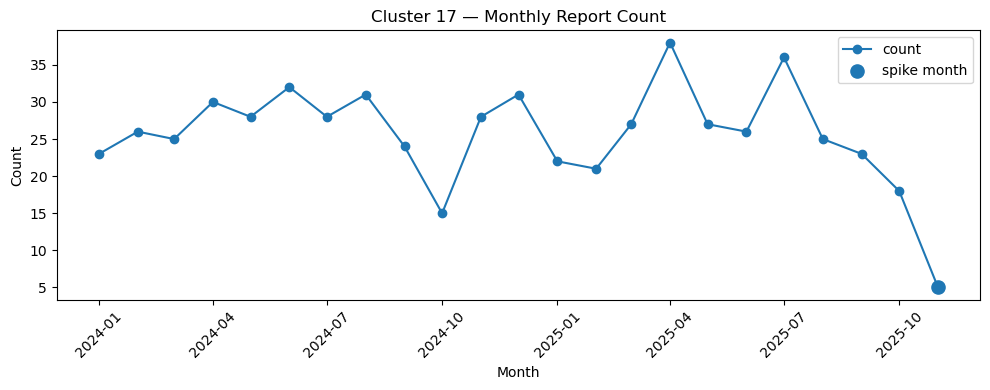

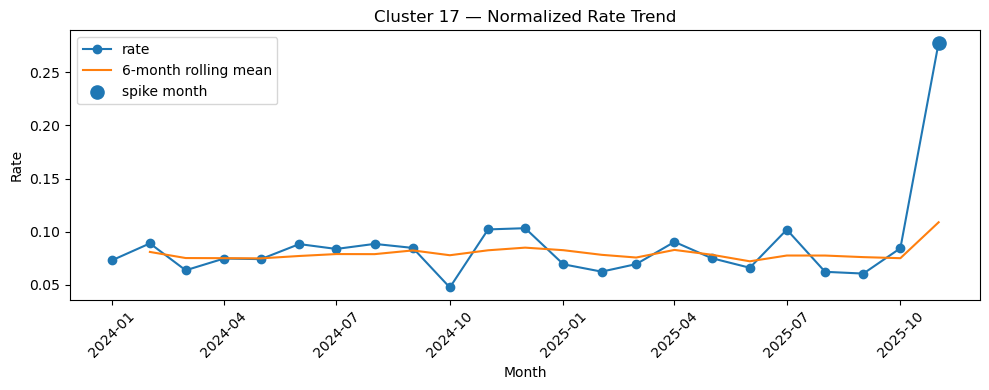

In [36]:
# ============================================================
# 12. PLOT ONE CLUSTER'S TREND
# ============================================================
# This function shows:
# - raw monthly count
# - normalized monthly rate
# - rolling mean of rate
# - highlighted spike months

def plot_cluster_rate(cluster_id):
    g = cluster_features_rate[
        cluster_features_rate[CLUSTER_COL] == cluster_id
    ].sort_values("month_key")

    # Trim the plot so it begins at the first active month
    if (g["count"] > 0).any():
        first_active = g.loc[g["count"] > 0, "month_key"].min()
        g = g[g["month_key"] >= first_active]

    sp = g[g["spike_flag"]]

    # --------------------------------------------
    # Plot 1: raw monthly counts
    # --------------------------------------------
    plt.figure(figsize=(10, 4))
    plt.plot(g["month_key"], g["count"], marker="o", label="count")

    if len(sp) > 0:
        plt.scatter(sp["month_key"], sp["count"], s=90, label="spike month")

    plt.title(f"Cluster {cluster_id} — Monthly Report Count")
    plt.xlabel("Month")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --------------------------------------------
    # Plot 2: normalized rate and rolling mean
    # --------------------------------------------
    plt.figure(figsize=(10, 4))
    plt.plot(g["month_key"], g["rate"], marker="o", label="rate")
    plt.plot(g["month_key"], g["rate_roll_mean"], label=f"{ROLLING_WINDOW}-month rolling mean")

    if len(sp) > 0:
        plt.scatter(sp["month_key"], sp["rate"], s=90, label="spike month")

    plt.title(f"Cluster {cluster_id} — Normalized Rate Trend")
    plt.xlabel("Month")
    plt.ylabel("Rate")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()


# Plot the cluster with the strongest spike, if any exist
if len(spikes_rate) > 0:
    top_cluster = (
        spikes_rate.groupby(CLUSTER_COL)["rate_z"]
                   .max()
                   .sort_values(ascending=False)
                   .index[0]
    )
    print("\nPlotting strongest spike cluster:", top_cluster)
    plot_cluster_rate(top_cluster)
else:
    print("\nNo spikes found with the current thresholds.")

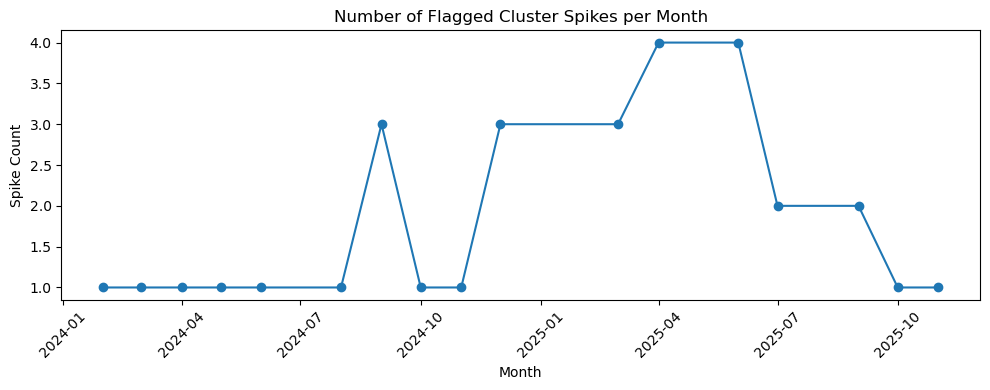

In [37]:
# ============================================================
# 13. PLOT NUMBER OF SPIKES PER MONTH
# ============================================================
# This gives a system-level view of how many clusters surged in
# each month.

spikes_per_month = spikes_rate.groupby("month_key").size()

plt.figure(figsize=(10, 4))
plt.plot(spikes_per_month.index, spikes_per_month.values, marker="o")
plt.title("Number of Flagged Cluster Spikes per Month")
plt.xlabel("Month")
plt.ylabel("Spike Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [38]:
# ============================================================
# 14. HEATMAP OF CLUSTER TREND INTENSITY
# ============================================================
# We use rate_z for the heatmap because it shows how abnormal each
# cluster-month is relative to that cluster's recent history.
#
# To keep the heatmap readable, only show the top N clusters by
# total report volume.

top_clusters = (
    cluster_features_rate.groupby(CLUSTER_COL)["count"]
    .sum()
    .sort_values(ascending=False)
    .head(TOP_N_HEATMAP)
    .index
    .tolist()
)

heat_df = cluster_features_rate[
    cluster_features_rate[CLUSTER_COL].isin(top_clusters)
].copy()

heat_pivot = heat_df.pivot_table(
    index=CLUSTER_COL,
    columns="month_key",
    values="rate_z",
    aggfunc="mean"
).sort_index()

# Format month labels nicely
heat_pivot.columns = pd.to_datetime(heat_pivot.columns).strftime("%Y-%m")

fig = px.imshow(
    heat_pivot,
    aspect="auto",
    labels=dict(x="Month", y="Cluster ID", color="Rate z-score"),
    title=f"Trend Heatmap (Top {TOP_N_HEATMAP} Clusters) — Rate z-score"
)

fig.show()

## 14b. Recent spike leaders (last N months)

Ranks clusters by strongest **normalized-rate** spike signal in the **most recent** calendar months (see `RECENT_SPIKE_MONTHS`).


In [39]:
# Requires cluster_features_rate from section 14
last_months = sorted(cluster_features_rate["month_key"].dropna().unique())[-RECENT_SPIKE_MONTHS:]
recent = cluster_features_rate[
    cluster_features_rate["month_key"].isin(last_months) & (cluster_features_rate["cluster_id"] >= 0)
].copy()
# Score = max |rate_z| per cluster in the window (how extreme vs its own rolling baseline)
score = recent.groupby("cluster_id")["rate_z"].max().sort_values(ascending=False)
top_recent = score.head(TOP_N_RECENT_SPIKE_CLUSTERS)
print("Months in window:", [pd.Timestamp(m).strftime("%Y-%m") for m in last_months])
print("Top clusters by max rate_z in window:\n", top_recent)

summary_recent = []
for cid, zmax in top_recent.items():
    row_m = recent[(recent["cluster_id"] == cid) & (recent["rate_z"] == zmax)]
    if row_m.empty:
        row_m = recent[recent["cluster_id"] == cid].sort_values("rate_z", ascending=False).head(1)
    r = row_m.iloc[0]
    name = ""
    if "name" in df.columns:
        sub = df[df["cluster_id"] == cid]
        if len(sub) and sub["name"].notna().any():
            name = str(sub["name"].dropna().iloc[0])
    summary_recent.append(
        {
            "cluster_id": cid,
            "max_rate_z": float(zmax),
            "month": pd.Timestamp(r["month_key"]).strftime("%Y-%m"),
            "count": int(r["count"]),
            "rate": float(r["rate"]),
            "name": name,
        }
    )
recent_spike_leaders = pd.DataFrame(summary_recent)
display(recent_spike_leaders)


Months in window: ['2025-09', '2025-10', '2025-11']
Top clusters by max rate_z in window:
 cluster_id
15    2.218031
17    2.195954
28    2.065666
2     2.063437
29    1.996697
Name: rate_z, dtype: float64


,cluster_id,max_rate_z,month,count,rate,name
0,15,2.218031,2025-11,6,0.333333,Taxi - Deviation / Discrepancy - Procedural Pu...
1,17,2.195954,2025-11,5,0.277778,Cruise - Inflight Event / Encounter Wake Vorte...
2,28,2.065666,2025-11,3,0.166667,Initial Approach - Deviation / Discrepancy - P...
3,2,2.063437,2025-10,10,0.046948,Final Approach - Airspace Violation All Types;...
4,29,1.996697,2025-09,14,0.036939,Cruise - ATC Issue All Types; Deviation / Disc...


In [40]:
# ============================================================
# TOP 3 SPIKE CLUSTERS - INTERACTIVE TIME-SERIES PLOTS
# ============================================================
# Purpose:
# Show the 3 strongest spike clusters with rich interactive hover info.
#
# This cell assumes you already ran your main time-series pipeline and
# created:
#   - cluster_features_rate   -> full cluster-month trend table
#   - spikes_rate             -> flagged spike rows from rate-based logic
#
# What this cell shows for each top cluster:
# - Cluster ID
# - Optional cluster label / name
# - Optional cluster description
# - Month
# - Monthly count
# - Monthly normalized rate
# - Rolling mean
# - z-score
# - growth %
# - whether the month was flagged as a spike
# - optional metadata like top anomaly / phase / aircraft / terms
# ============================================================

import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

# ------------------------------------------------------------
# 1. BASIC SAFETY CHECKS
# ------------------------------------------------------------
required_objects = ["cluster_features_rate", "spikes_rate"]
missing_objects = [obj for obj in required_objects if obj not in globals()]

if missing_objects:
    raise ValueError(
        f"Missing required objects: {missing_objects}. "
        "Run the main time-series pipeline first."
    )

if len(spikes_rate) == 0:
    raise ValueError(
        "No spike rows found in 'spikes_rate'. "
        "Try loosening thresholds or confirm spike detection ran correctly."
    )

# ------------------------------------------------------------
# 2. OPTIONAL: MERGE CLUSTER METADATA IF AVAILABLE
# ------------------------------------------------------------
# If your original dataframe df contains cluster-level descriptive columns,
# bring one representative row per cluster into the plotting dataframe.
meta_candidates = [
    "name",
    "description",
    "top_anomaly",
    "top_phase",
    "top_aircraft",
    "top_terms"
]

plot_df = cluster_features_rate.copy()

if "df" in globals():
    available_meta = [c for c in meta_candidates if c in df.columns]

    if available_meta:
        cluster_meta = (
            df[["cluster_id"] + available_meta]
            .drop_duplicates(subset=["cluster_id"])
            .copy()
        )

        cols_to_merge = ["cluster_id"] + [
            c for c in available_meta if c not in plot_df.columns
        ]

        if len(cols_to_merge) > 1:
            plot_df = plot_df.merge(
                cluster_meta[cols_to_merge],
                on="cluster_id",
                how="left"
            )

# ------------------------------------------------------------
# 3. CREATE FRIENDLIER DISPLAY COLUMNS
# ------------------------------------------------------------
# Your earlier pipeline names:
#   count-based: rolling_mean, z_score, growth_pct
#   rate-based : rate_roll_mean, rate_z, rate_growth_pct
#
# To make plotting easier, create standardized aliases.
plot_df = plot_df.copy()

if "month_key" in plot_df.columns:
    plot_df["month_str"] = pd.to_datetime(plot_df["month_key"]).dt.strftime("%Y-%m")

# Count-side aliases
if "rolling_mean" in plot_df.columns:
    plot_df["rolling_mean_count"] = plot_df["rolling_mean"]

if "rolling_std" in plot_df.columns:
    plot_df["rolling_std_count"] = plot_df["rolling_std"]

if "z_score" in plot_df.columns:
    plot_df["z_count"] = plot_df["z_score"]

if "growth_pct" in plot_df.columns:
    plot_df["growth_pct_count"] = plot_df["growth_pct"]

# Rate-side aliases
if "rate_roll_mean" in plot_df.columns:
    plot_df["rolling_mean_rate"] = plot_df["rate_roll_mean"]

if "rate_roll_std" in plot_df.columns:
    plot_df["rolling_std_rate"] = plot_df["rate_roll_std"]

if "rate_z" in plot_df.columns:
    plot_df["z_rate"] = plot_df["rate_z"]

if "rate_growth_pct" in plot_df.columns:
    plot_df["growth_pct_rate"] = plot_df["rate_growth_pct"]

# Standardized spike aliases
if "spike_rate_z" in plot_df.columns:
    plot_df["spike_rate"] = plot_df["spike_rate_z"]

if "spike_z" in plot_df.columns:
    plot_df["spike_count"] = plot_df["spike_z"]

# Previous month's count for hover context
plot_df["prev_count"] = plot_df.groupby("cluster_id")["count"].shift(1)

# ------------------------------------------------------------
# 4. RANK CLUSTERS AND PICK TOP 3
# ------------------------------------------------------------
# We rank clusters by their strongest spike signal.
# If both count and rate z-scores exist, use the stronger of the two.
rank_cols = [c for c in ["z_count", "z_rate"] if c in spikes_rate.columns or c in plot_df.columns]

# Build ranking table from plot_df rows that were flagged as spikes
spike_rows_for_rank = plot_df[plot_df["spike_flag"] == True].copy()

if "z_count" not in spike_rows_for_rank.columns:
    spike_rows_for_rank["z_count"] = np.nan

if "z_rate" not in spike_rows_for_rank.columns:
    spike_rows_for_rank["z_rate"] = np.nan

spike_rank = (
    spike_rows_for_rank.groupby("cluster_id")[["z_count", "z_rate"]]
    .max()
    .fillna(-np.inf)
)

spike_rank["spike_score"] = spike_rank[["z_count", "z_rate"]].max(axis=1)

top3_clusters = (
    spike_rank.sort_values("spike_score", ascending=False)
    .head(3)
    .reset_index()
)

print("Top 3 spike clusters:")
display(top3_clusters)

top_cluster_ids = top3_clusters["cluster_id"].tolist()

# ------------------------------------------------------------
# 5. HELPER FUNCTION: HOVER COLUMN MAP
# ------------------------------------------------------------
def get_hover_columns(g):
    """
    Return only the columns that actually exist in this dataframe,
    with formatting where appropriate.
    """
    hover_map = {}

    candidate_hover = {
        "month_str": True,
        "count": True,
        "month_total": True,
        "rate": ":.4f",
        "prev_count": True,
        "rolling_mean_count": ":.2f",
        "rolling_std_count": ":.2f",
        "z_count": ":.2f",
        "growth_pct_count": ":.1f",
        "rolling_mean_rate": ":.4f",
        "rolling_std_rate": ":.4f",
        "z_rate": ":.2f",
        "growth_pct_rate": ":.1f",
        "spike_count": True,
        "spike_rate": True,
        "spike_flag": True,
        "name": True,
        "description": True,
        "top_anomaly": True,
        "top_phase": True,
        "top_aircraft": True,
        "top_terms": True,
    }

    for col, fmt in candidate_hover.items():
        if col in g.columns:
            hover_map[col] = fmt

    return hover_map

# ------------------------------------------------------------
# 6. PLOT TOP 3 SPIKE CLUSTERS
# ------------------------------------------------------------
for cid in top_cluster_ids:
    g = plot_df[plot_df["cluster_id"] == cid].copy()
    g = g.sort_values("month_key")

    if len(g) == 0:
        continue

    # Trim leading months before the cluster first appears
    active = g[g["count"] > 0]
    if len(active) == 0:
        continue

    first_active_month = active["month_key"].min()
    g = g[g["month_key"] >= first_active_month].copy()

    # Optional metadata for titles / printed description
    cluster_name = ""
    if "name" in g.columns and g["name"].notna().any():
        cluster_name = g["name"].dropna().iloc[0]

    cluster_desc = ""
    if "description" in g.columns and g["description"].notna().any():
        cluster_desc = g["description"].dropna().iloc[0]

    title_suffix = f" — {cluster_name}" if cluster_name else ""
    hover_cols = get_hover_columns(g)

    # Identify spike points for highlighted markers
    spike_points = g[g["spike_flag"] == True].copy() if "spike_flag" in g.columns else pd.DataFrame()

    # --------------------------------------------------------
    # 6A. MONTHLY COUNT PLOT
    # --------------------------------------------------------
    fig_count = px.line(
        g,
        x="month_key",
        y="count",
        markers=True,
        hover_data=hover_cols,
        title=f"Cluster {cid}{title_suffix} — Monthly Report Count"
    )

    # Add count rolling mean if available
    if "rolling_mean_count" in g.columns:
        fig_count.add_trace(
            go.Scatter(
                x=g["month_key"],
                y=g["rolling_mean_count"],
                mode="lines",
                name="Rolling Mean Count"
            )
        )

    # Highlight spike months
    if len(spike_points) > 0:
        fig_count.add_trace(
            go.Scatter(
                x=spike_points["month_key"],
                y=spike_points["count"],
                mode="markers",
                name="Spike Month",
                marker=dict(size=12, symbol="circle")
            )
        )

    fig_count.update_layout(
        xaxis_title="Month",
        yaxis_title="Monthly Report Count",
        hovermode="x unified"
    )

    fig_count.show()

    # --------------------------------------------------------
    # 6B. NORMALIZED RATE / SHARE PLOT
    # --------------------------------------------------------
    if "rate" in g.columns:
        fig_rate = px.line(
            g,
            x="month_key",
            y="rate",
            markers=True,
            hover_data=hover_cols,
            title=f"Cluster {cid}{title_suffix} — Normalized Rate Trend"
        )

        # Add rolling mean for normalized rate
        if "rolling_mean_rate" in g.columns:
            fig_rate.add_trace(
                go.Scatter(
                    x=g["month_key"],
                    y=g["rolling_mean_rate"],
                    mode="lines",
                    name="Rolling Mean Rate"
                )
            )

        # Highlight spike months
        if len(spike_points) > 0:
            fig_rate.add_trace(
                go.Scatter(
                    x=spike_points["month_key"],
                    y=spike_points["rate"],
                    mode="markers",
                    name="Spike Month",
                    marker=dict(size=12, symbol="circle")
                )
            )

        fig_rate.update_layout(
            xaxis_title="Month",
            yaxis_title="Cluster Share of Monthly Reports",
            hovermode="x unified"
        )

        fig_rate.show()

    # --------------------------------------------------------
    # 6C. PRINT DESCRIPTION UNDER THE PLOTS
    # --------------------------------------------------------
    if cluster_desc:
        print(f"Cluster {cid} description: {cluster_desc}\n")

Top 3 spike clusters:


,cluster_id,z_count,z_rate,spike_score
0,17,-inf,2.195954,2.195954
1,27,-inf,2.056431,2.056431
2,22,-inf,2.052677,2.052677


Cluster 17 description: Incidents in Cruise. Common theme: Inflight Event / Encounter Wake Vortex Encounter. Aircraft: B737 Undifferentiated or Other Model.



Cluster 27 description: Incidents in Cruise. Common theme: Deviation / Discrepancy - Procedural FAR; Deviation / Discre. Aircraft: Skyhawk 172/Cutlass 172.



Cluster 22 description: Incidents in Parked. Common theme: Aircraft Equipment Problem Critical. Aircraft: B737 Undifferentiated or Other Model.



## 15. Export reports (CSV)

Writes `cluster_labels_report.csv` and `recent_spikes_report.csv` next to the data (same folder as `DATA_CSV`).


In [48]:
import os
import re

_out = os.path.dirname(os.path.abspath(DATA_CSV)) if DATA_CSV else os.getcwd()
os.makedirs(_out, exist_ok=True)


def _export_simple_causal_summary(row):
    """Short, plain-language causal summary with likely cause drivers."""
    try:
        n = int(float(row.get("size", 0) or 0))
    except Exception:
        n = 0
    phase = str(row.get("top_phase", "") or "").strip()
    name = str(row.get("name", "") or "").strip()
    keywords = str(row.get("keywords", "") or "").strip().lower()
    purity = str(row.get("purity_context", "") or "").strip().lower()

    issue = name.split(" - ", 1)[1] if " - " in name else name
    issue = issue.strip().lower()

    kw = [k.strip() for k in keywords.split(",") if k.strip()][:6]
    kw_txt = ", ".join(kw)

    driver_rules = [
        ("system / equipment reliability", ["engine", "hydraulic", "electrical", "smoke", "fire", "gear", "flap", "trim", "pressur", "oil", "failure"]),
        ("procedural compliance / SOP adherence", ["procedure", "policy", "checklist", "published", "clearance", "unstabilized", "deviation"]),
        ("ATC communication / coordination", ["atc", "tower", "center", "frequency", "controller", "hearback", "readback"]),
        ("airspace conflict / traffic separation", ["nmac", "ra", "tcas", "traffic", "conflict", "separation", "drone", "uas"]),
        ("weather / turbulence exposure", ["turbulence", "wake", "windshear", "crosswind", "icing", "weather"]),
        ("ground movement / surface operations", ["taxi", "runway", "gate", "pushback", "ramp", "ground"]),
    ]

    signals = " ".join([issue, keywords, purity])
    drivers = [label for label, pats in driver_rules if any(p in signals for p in pats)]
    if not drivers:
        drivers = ["mixed operational and human-factor conditions"]

    s1 = f"Cluster {int(float(row.get('cluster_id', -1) or -1))} contains {n} reports, mostly in the {phase.lower() if phase else 'reported'} phase."
    s2 = f"Likely cause drivers are {', '.join(drivers[:2])}."
    s3 = f"The recurring event pattern is {issue}." if issue else "The reports describe a recurring operational safety issue."
    s4 = f"Evidence appears in repeated terms: {kw_txt}." if kw_txt else "Evidence appears across repeated narrative patterns."
    s5 = "This is an inferred causal pattern from clustered reports, not a proven single root cause."

    txt = " ".join([s1, s2, s3, s4, s5])
    txt = " ".join(txt.split())
    parts = re.split(r"(?<=[.!?])\s+", txt)
    parts = [p.strip() for p in parts if p.strip()]
    return " ".join(parts[:5])


if "cluster_labels_llm" in dir() and cluster_labels_llm is not None and len(cluster_labels_llm):
    p1 = os.path.join(_out, "cluster_labels_report.csv")
    _export_df = cluster_labels_llm.copy()
    _export_df["causal_summary"] = _export_df.apply(_export_simple_causal_summary, axis=1)
    _export_df.to_csv(p1, index=False)
    print("Wrote", p1)
else:
    print("Skip cluster_labels_report.csv (cluster_labels_llm missing or empty)")

if "recent_spike_leaders" in dir() and recent_spike_leaders is not None and len(recent_spike_leaders):
    p2 = os.path.join(_out, "recent_spikes_report.csv")
    recent_spike_leaders.to_csv(p2, index=False)
    print("Wrote", p2)
else:
    print("Skip recent_spikes_report.csv (run time-series + section 14b first, or empty table)")


Wrote /Users/avantikatiwarii/Desktop/capston project FINAL/cluster_labels_report.csv
Wrote /Users/avantikatiwarii/Desktop/capston project FINAL/recent_spikes_report.csv


## 16. RAG — regulation mapping (FAA / CFR corpus)

**Goal:** From a **detected trend string** (e.g. cluster label or spike summary), retrieve the top matching **regulation / AC / SAFO** chunks via embeddings + ChromaDB — no LLM required for retrieval.

**Corpus layout:** Put PDFs or `.txt` files under `faa_corpus/` next to your data (see config). Minimum demo: fetch **14 CFR Part 91** via the **official eCFR versioner API** (bulk Title 14 XML, then extract Part 91)—not the HTML reader (Colab often gets a bot-block page there). Then add **AC** PDFs from the [FAA Advisory Circulars](https://www.faa.gov/regulations_policies/advisory_circulars) index when you have time.

**Steps implemented in code:** scan corpus → chunk (tokenizer windows for local MiniLM, or character windows if using EurON) → **embeddings** (local `sentence-transformers` *or* EurON OpenAI-style `/embeddings` with the same API key as chat) → Chroma collection `faa_regulations` → `query_trend_for_regulations(...)`.


In [46]:
import sys

# Notebook cwd may differ from the folder that contains this repo — add project root
_nb_dir = os.getcwd()
if _nb_dir not in sys.path:
    sys.path.insert(0, _nb_dir)

from faa_regulation_rag import (
    PRIORITY_ADVISORY_CIRCULARS,
    fetch_ecfr_part_91_to_txt,
    ingest_faa_corpus,
    query_trend_for_regulations,
    format_regulation_report,
)

os.makedirs(FAA_CORPUS_DIR, exist_ok=True)

# Drop legacy HTML scrape file if it is the bot-block page (relevance ~0.01 garbage)
_legacy_p91 = os.path.join(FAA_CORPUS_DIR, "14_cfr_part_91_ecfr.txt")
if os.path.isfile(_legacy_p91):
    _probe = open(_legacy_p91, encoding="utf-8", errors="replace").read(2000).lower()
    if "captcha" in _probe or "automated scraping" in _probe or "bot test" in _probe:
        os.remove(_legacy_p91)
        print("Removed junk Part 91 cache (HTML bot block):", _legacy_p91)

# Optional: Part 91 plain text via eCFR API (Title 14 XML → extract Part 91)
_part91_txt = os.path.join(FAA_CORPUS_DIR, "14_cfr_part_91_api.txt")
if not os.path.isfile(_part91_txt):
    try:
        fetch_ecfr_part_91_to_txt(_part91_txt)
        print("Saved eCFR Part 91 text ->", _part91_txt)
    except Exception as _e:
        print("Skipping eCFR fetch (add PDFs/txt under faa_corpus/ instead):", _e)
else:
    print("Part 91 text already present:", _part91_txt)

print("Priority ACs to add as PDFs when available:")
for _ac in PRIORITY_ADVISORY_CIRCULARS:
    print(" ", _ac)

# --- Auto-download high-impact GPS interference doc(s) ---
FAA_DOC_URLS = {
    # Biggest win for your specific trend
    "AC_90-114A.pdf": "https://www.faa.gov/documentLibrary/media/Advisory_Circular/AC_90-114A.pdf",

    # Add more URLs here as you choose (SAFOs/other ACs). Example pattern:
    # "SAFO_21-11.pdf": "<paste official FAA PDF url>",
}

def _download_if_missing(name, url, out_dir):
    import requests

    os.makedirs(out_dir, exist_ok=True)
    out_path = os.path.join(out_dir, name)
    if os.path.isfile(out_path) and os.path.getsize(out_path) > 50_000:
        return out_path
    r = requests.get(url, timeout=180)
    r.raise_for_status()
    with open(out_path, "wb") as f:
        f.write(r.content)
    print("Downloaded ->", out_path)
    return out_path

for _name, _url in FAA_DOC_URLS.items():
    try:
        _download_if_missing(_name, _url, FAA_CORPUS_DIR)
    except Exception as _e:
        print("Download skipped:", _name, "|", _e)

# Embeddings: local BGE only (no EurON)
_faa_rag_kw = {}
print("FAA RAG embeddings: local", EMBEDDING_MODEL)

try:
    _ingest = ingest_faa_corpus(
        corpus_dir=FAA_CORPUS_DIR,
        chroma_persist_dir=FAA_CHROMA_DIR,
        embedding_model_name=EMBEDDING_MODEL,
        max_tokens=FAA_RAG_CHUNK_TOKENS,
        overlap=FAA_RAG_CHUNK_OVERLAP,
        force_rebuild=FORCE_REBUILD_FAA_RAG,
        **_faa_rag_kw,
    )
    print(f"FAA RAG index ready: {_ingest.n_chunks} chunks -> {_ingest.chroma_path}")
except FileNotFoundError as _e:
    raise RuntimeError(
        "No corpus files yet. Fix eCFR fetch errors above or add PDF/TXT under faa_corpus/, then re-run."
    ) from _e

# Build a more regulatory-aligned query string (usually improves retrieval)
# If you have cluster keywords / narrative snippets, append them here too.
_base_trend = "GPS interference during approach and navigation equipment degradation"
_query = "\n".join(
    [
        _base_trend,
        "IFR navigation equipment requirements",
        "GNSS / GPS signal loss or degradation procedures",
        "GPS interference reporting requirements (ATC reporting)",
        "approach procedures when navigation becomes unreliable",
        "alternative navigation systems (VOR/DME, ILS, radar vectors)",
    ]
)

_hits = query_trend_for_regulations(
    _query,
    chroma_persist_dir=FAA_CHROMA_DIR,
    embedding_model_name=EMBEDDING_MODEL,
    top_k=FAA_RAG_TOP_K,
    **_faa_rag_kw,
)
print(format_regulation_report(_base_trend, _hits))


Part 91 text already present: /Users/avantikatiwarii/Desktop/capston project FINAL/faa_corpus/14_cfr_part_91_api.txt
Priority ACs to add as PDFs when available:
  AC 90-114A
  AC 90-100A
  AC 91-74B
  AC 120-51E
  AC 120-71B
  AC 20-138D
  AC 25-11B
  AC 25-7D
  AC 20-115D
  AC 00-24C
  AC 00-45H
  AC 91-51A
  AC 60-22
  AC 120-92A
  AC 120-103A
Download skipped: AC_90-114A.pdf | 404 Client Error: Not Found for url: https://www.faa.gov/documentLibrary/media/Advisory_Circular/AC_90-114A.pdf
FAA RAG embeddings: local BAAI/bge-base-en-v1.5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

FAA RAG index ready: 4017 chunks -> /Users/avantikatiwarii/Desktop/capston project FINAL/chroma_faa_regulations


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


TREND: GPS interference during approach and navigation equipment degradation

RELEVANT REGULATIONS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📋 AC 90-114C  (relevance: 0.77)
   "nd other handbooks and manuals for information on the differences between device failures and function failures and the implications and procedures associated with each failure type. in particular, normal gnss signal interference on the ground caused by nearby obstacles, such as a large hangar, may be incorrectly interpreted as a failure of the ads - b system. moving the aircraft clear of"

📋 AC 90-114B CHG 1  (relevance: 0.77)
   "nuals for information on the differences between device failures and function failures and the implications and procedures associated with each failure type. in particular, normal gnss signal interference on the ground caused by nearby obstacles, such as a large hangar, may be incorrectly interpreted as a failure of the ads - b system. moving the aircraft clear of obstructions may be 

In [43]:
pip freeze

absl-py==2.2.0
accelerate==1.13.0
aext-assistant @ file:///private/var/folders/nz/j6p8yfhx1mv_0grj5xl4650h0000gp/T/abs_5blio7a88h/croot/aext-assistant_1717062156186/work
aext-assistant-server @ file:///private/var/folders/nz/j6p8yfhx1mv_0grj5xl4650h0000gp/T/abs_84ykzx_q85/croot/aext-assistant-server_1717059976819/work
aext-core @ file:///private/var/folders/nz/j6p8yfhx1mv_0grj5xl4650h0000gp/T/abs_6230gwvics/croot/aext-core_1717056412538/work
aext-core-server @ file:///private/var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_8eywdkec83/croot/aext-core-server_1717075040870/work
aext-panels @ file:///private/var/folders/nz/j6p8yfhx1mv_0grj5xl4650h0000gp/T/abs_70wky0p3yf/croot/aext-panels_1717062185397/work
aext-panels-server @ file:///private/var/folders/nz/j6p8yfhx1mv_0grj5xl4650h0000gp/T/abs_ce_grc3i0p/croot/aext-panels-server_1717060164537/work
aext-share-notebook @ file:///private/var/folders/nz/j6p8yfhx1mv_0grj5xl4650h0000gp/T/abs_72nt4kju8z/croot/aext-share-notebook_1717059289451